In [309]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

## Read the data 

In [284]:
df = pd.read_csv("../dataset/motorcycles_clean.csv")

In [285]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              362 non-null    str    
 1   Country of Origin    362 non-null    str    
 2   Model                362 non-null    str    
 3   Number of cc         361 non-null    float64
 4   Horsepower           362 non-null    float64
 5   Torque               361 non-null    float64
 6   Transmission Type    362 non-null    str    
 7   Drivetrain           362 non-null    str    
 8   Number of Seating    362 non-null    int64  
 9   Year                 362 non-null    int64  
 10  Looks                362 non-null    str    
 11  Body Type            362 non-null    str    
 12  Engine Type          362 non-null    str    
 13  Number of Cylinders  360 non-null    float64
 14  Price (SEK)          362 non-null    float64
dtypes: float64(5), int64(2), str(8)
memory usage: 42.6 

In [286]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 358 entries, 0 to 361
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              358 non-null    str    
 1   Country of Origin    358 non-null    str    
 2   Model                358 non-null    str    
 3   Number of cc         358 non-null    float64
 4   Horsepower           358 non-null    float64
 5   Torque               358 non-null    float64
 6   Transmission Type    358 non-null    str    
 7   Drivetrain           358 non-null    str    
 8   Number of Seating    358 non-null    int64  
 9   Year                 358 non-null    int64  
 10  Looks                358 non-null    str    
 11  Body Type            358 non-null    str    
 12  Engine Type          358 non-null    str    
 13  Number of Cylinders  358 non-null    float64
 14  Price (SEK)          358 non-null    float64
dtypes: float64(5), int64(2), str(8)
memory usage: 44.8 KB


## Spliting the data

In [287]:
categorical_features = ["Company"]

numeric_features = [
    "Number of cc",
    "Horsepower",
    "Torque",
    "Year",
    "Price (SEK)",
    "Number of Cylinders"
]

x = df[categorical_features + numeric_features]
y = df["Price (SEK)"]

## Train, Val, Test

In [288]:
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=42)

In [289]:
# Convert categorical features to numerical values and keep numerical features unchanged.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

## Linear regression
initialising train and prediction

In [290]:
lin_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())])
lin_reg.fit(x_train, y_train)
lin_reg_pred = lin_reg.predict(x_val)

In [291]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

result = regression_metrics(y_val, lin_reg_pred)
print(result)

{'RMSE': 0.01435743009428807, 'MSE': 0.00020613579891236872, 'MAE': 0.006990120741475352}


## First evaluation for linear regression and it preformed not as well as i would hope.

===================================================================================================================================================================

## Trying forest with hyper params

In [292]:
# Pipelina for the forestregression model 
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_split=3,
                min_samples_leaf=1,
                random_state=42
            )
        )
    ]
)

In [293]:
tree_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))])
hyperparameters = {
    "model__n_estimators": [210, 220, 230],
    "model__max_depth": [None, 1, 5],
    "model__min_samples_split": [2, 3, 5],
    "model__min_samples_leaf": [1, 2, 4]
}

tree_reg_gs = GridSearchCV(tree_reg, hyperparameters, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
tree_reg_gs.fit(x_train, y_train)

tree_reg_pred = tree_reg_gs.predict(x_val)
print("Best hyperparameters:", tree_reg_gs.best_params_)
pd.DataFrame(tree_reg_gs.cv_results_)

Best hyperparameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 220}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.473793,0.020019,0.028465,0.001507,None,1,2,210,"{'model__max_depth': None, 'model__min_samples...",-1.323649e+09,-9.803693e+05,-2.201050e+06,-1.942325e+07,-2.760505e+06,-2.698029e+08,5.269668e+08,3
1,0.523729,0.061111,0.030616,0.002207,None,1,2,220,"{'model__max_depth': None, 'model__min_samples...",-1.312655e+09,-9.681287e+05,-2.085559e+06,-1.988072e+07,-2.697624e+06,-2.676574e+08,5.225453e+08,1
2,0.531629,0.040819,0.031892,0.003042,None,1,2,230,"{'model__max_depth': None, 'model__min_samples...",-1.313620e+09,-9.555348e+05,-2.041925e+06,-1.994452e+07,-2.779527e+06,-2.678684e+08,5.229229e+08,2
3,0.410153,0.014130,0.028552,0.001871,None,1,3,210,"{'model__max_depth': None, 'model__min_samples...",-1.351128e+09,-1.816332e+06,-2.348178e+06,-2.227633e+07,-3.015340e+06,-2.761169e+08,5.375610e+08,10
4,0.419878,0.022050,0.037667,0.012357,None,1,3,220,"{'model__max_depth': None, 'model__min_samples...",-1.340017e+09,-1.716626e+06,-2.397784e+06,-2.268434e+07,-2.953096e+06,-2.739537e+08,5.330898e+08,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,0.367717,0.029318,0.029236,0.000984,5,4,3,220,"{'model__max_depth': 5, 'model__min_samples_le...",-1.737526e+09,-3.761797e+07,-3.546742e+06,-7.152289e+07,-3.133791e+07,-3.763104e+08,6.809517e+08,46
77,0.359755,0.026882,0.029637,0.006091,5,4,3,230,"{'model__max_depth': 5, 'model__min_samples_le...",-1.738435e+09,-3.718802e+07,-3.430849e+06,-7.216209e+07,-3.047428e+07,-3.763381e+08,6.814009e+08,49
78,0.320094,0.013447,0.027204,0.000494,5,4,5,210,"{'model__max_depth': 5, 'model__min_samples_le...",-1.741318e+09,-3.734544e+07,-3.582415e+06,-7.087379e+07,-3.085907e+07,-3.767957e+08,6.825974e+08,52
79,0.317795,0.012602,0.021717,0.006247,5,4,5,220,"{'model__max_depth': 5, 'model__min_samples_le...",-1.737526e+09,-3.761797e+07,-3.546742e+06,-7.152289e+07,-3.133791e+07,-3.763104e+08,6.809517e+08,46


In [294]:
tree_rmse = root_mean_squared_error(y_val,tree_reg_pred)
tree_mse = mean_squared_error(y_val, tree_reg_pred)

print("RMSE tree_regresssion: ", tree_rmse)
print("RME tree_regression: ", tree_mse)

RMSE tree_regresssion:  10936.709234558024
RME tree_regression:  119611608.88126677


In [295]:
# This is for forrestRegression from the flow of pipeline and model in the block above
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# evalutation
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")

RMSE: 59,142.20
MAE:  9,445.13


In [296]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(x_train, y_train)

dummy_pred = dummy.predict(x_test)

dummy_rmse = root_mean_squared_error(y_test, dummy_pred)

print("Dummy RMSE: ", dummy_rmse)


Dummy RMSE:  146548.6080833445


In [297]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 3, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 8]
}

random_search = RandomizedSearchCV(
    estimator=tree_reg,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'model__n_estimators': 100, 'model__min_samples_split': 3, 'model__min_samples_leaf': 2, 'model__max_depth': None}
-8710.312707430912


In [298]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(x_test)

test_rmse = root_mean_squared_error(y_test, y_pred)

print("Test RMSE: ", test_rmse)


Test RMSE:  61754.29033577394


## trying to add more values in the categorical_features and numeric_feature

In [299]:
categorical_features = ["Company", "Body Type", "Looks"]

numeric_features = [
    "Number of cc",
    "Horsepower",
    "Torque",
    "Year",
    "Price (SEK)",
    "Number of Cylinders",
    "Number of Seating"
]

x = df[categorical_features + numeric_features]
y = df["Price (SEK)"]

In [300]:
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=42)

In [301]:
# Convert categorical features to numerical values and keep numerical features unchanged.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [302]:
lin_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())])
lin_reg.fit(x_train, y_train)
lin_reg_pred = lin_reg.predict(x_val)

In [303]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

result = regression_metrics(y_val, lin_reg_pred)
print(result)

{'RMSE': 0.014357325148283456, 'MSE': 0.00020613278541353256, 'MAE': 0.006991034652087521}


### first valuation with minimal amount of variables 
{'RMSE': 0.01435743009428807, 'MSE': 0.00020613579891236872, 'MAE': 0.006990120741475352}
### Second valuation with more variables
{'RMSE': 0.01435732514828345, 'MSE': 0.00020613278541353256, 'MAE': 0.006991034652087521}

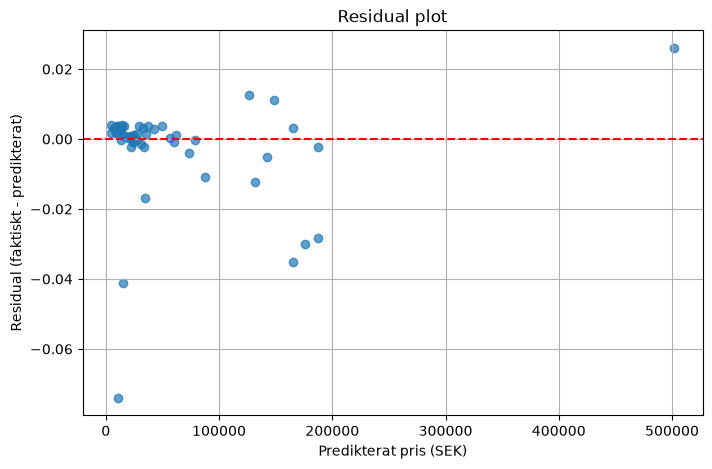

In [317]:
residuals = y_val - lin_reg_pred

plt.figure(figsize=(8, 5))

plt.scatter(lin_reg_pred, residuals, alpha=0.7)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predikterat pris (SEK)")
plt.ylabel("Residual (faktiskt - predikterat)")
plt.title("Residual plot")
plt.grid(True)

plt.show()


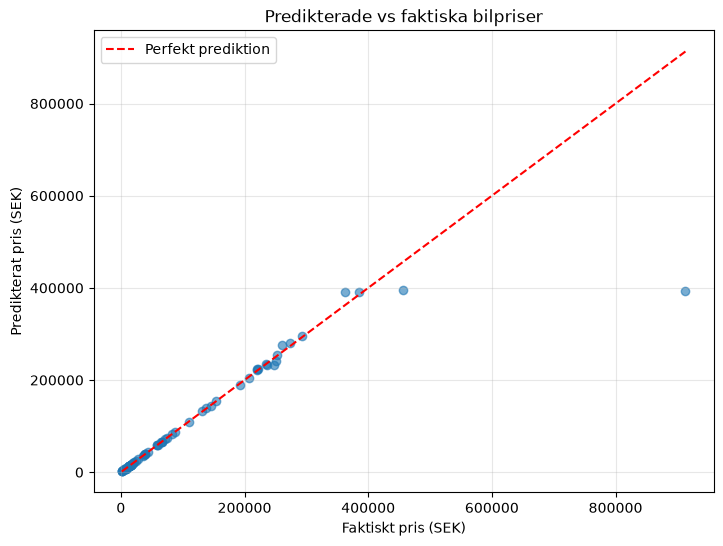

In [318]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Linje för perfekta prediktioner
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color="red",
    linestyle="--",
    label="Perfekt prediktion"
)

plt.xlabel("Faktiskt pris (SEK)")
plt.ylabel("Predikterat pris (SEK)")
plt.title("Predikterade vs faktiska bilpriser")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


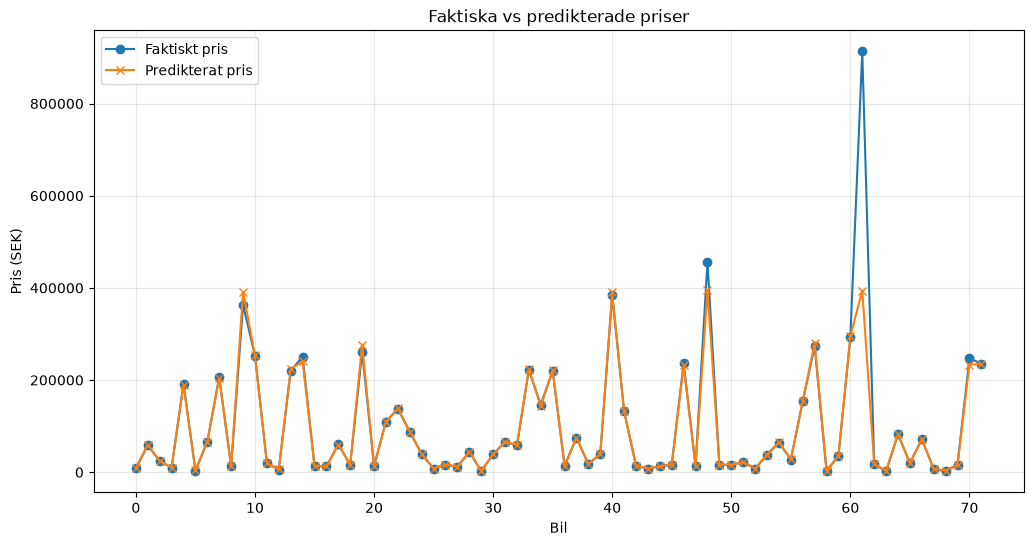

In [319]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label="Faktiskt pris", marker="o")
plt.plot(y_pred, label="Predikterat pris", marker="x")

plt.xlabel("Bil")
plt.ylabel("Pris (SEK)")
plt.title("Faktiska vs predikterade priser")
plt.legend()
plt.grid(alpha=0.3)

plt.show()
